In [42]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [43]:
df = pd.read_excel('preventiq_synthetic_india_health_data_with_district_names.xlsx')
display(df.head())

,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,days_since_last_visit,followup_delay_days,screening_completed,vaccination_up_to_date,facility_access_km,region_health_index,pgi,risk_score,risk_label,intervention_priority
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,28,15-29,Female,5,...,138,125,0,0,9.8,82.7,0.980,50.9,Medium,Moderate
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,47,45-59,Female,4,...,206,191,1,1,10.4,76.3,1.568,86.5,High,Immediate
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,13,0-14,Female,3,...,127,125,1,1,4.5,90.6,0.450,27.5,Low,Routine
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,53,45-59,Female,4,...,137,137,0,1,11.1,85.5,0.779,31.7,Low,Routine
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,31,30-44,Male,6,...,230,225,0,1,16.1,74.6,1.328,51.1,Medium,Moderate


In [44]:
# Summary statistics and info
print("--- Data Information ---")
display(df.info())
print("\n--- Missing Values ---")
display(df.isnull().sum())
print("\n--- Statistical Summary ---")
display(df.describe())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               24000 non-null  object 
 1   state_or_ut             24000 non-null  object 
 2   entity_type             24000 non-null  object 
 3   district                24000 non-null  object 
 4   district_name           24000 non-null  object 
 5   locality_type           24000 non-null  object 
 6   age                     24000 non-null  int64  
 7   age_group               24000 non-null  object 
 8   gender                  24000 non-null  object 
 9   household_size          24000 non-null  int64  
 10  literacy_status         24000 non-null  object 
 11  income_bracket          24000 non-null  object 
 12  occupation_type         24000 non-null  object 
 13  chronic_disease         24000 non-null  int64  
 14  hypertension 

None


--- Missing Values ---


,0
record_id,0
state_or_ut,0
entity_type,0
district,0
district_name,0
locality_type,0
age,0
age_group,0
gender,0
household_size,0



--- Statistical Summary ---


,age,household_size,chronic_disease,hypertension,diabetes,asthma,missed_visits_12m,missed_screenings_12m,days_since_last_visit,followup_delay_days,screening_completed,vaccination_up_to_date,facility_access_km,region_health_index,pgi,risk_score
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,33.668083,4.820833,0.273542,0.184333,0.154208,0.066667,1.407875,0.798042,156.898042,147.373333,0.517375,0.580917,10.558763,74.958400,0.782179,39.197513
std,17.505157,1.564316,0.445786,0.387764,0.361156,0.249449,1.280136,0.967493,52.257666,52.533973,0.499708,0.493419,4.096982,9.637358,0.415895,20.755115
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,21.100000,0.000000,0.000000
25%,21.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,122.000000,112.000000,0.000000,0.000000,7.400000,69.000000,0.483000,23.500000
50%,33.000000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,158.000000,149.000000,1.000000,1.000000,11.400000,75.500000,0.723000,33.100000
75%,46.000000,6.000000,1.000000,0.000000,0.000000,0.000000,2.000000,1.000000,192.000000,183.000000,1.000000,1.000000,13.700000,81.900000,1.021000,51.500000
max,90.000000,11.000000,1.000000,1.000000,1.000000,1.000000,8.000000,6.000000,368.000000,368.000000,1.000000,1.000000,23.000000,97.900000,2.973000,100.000000


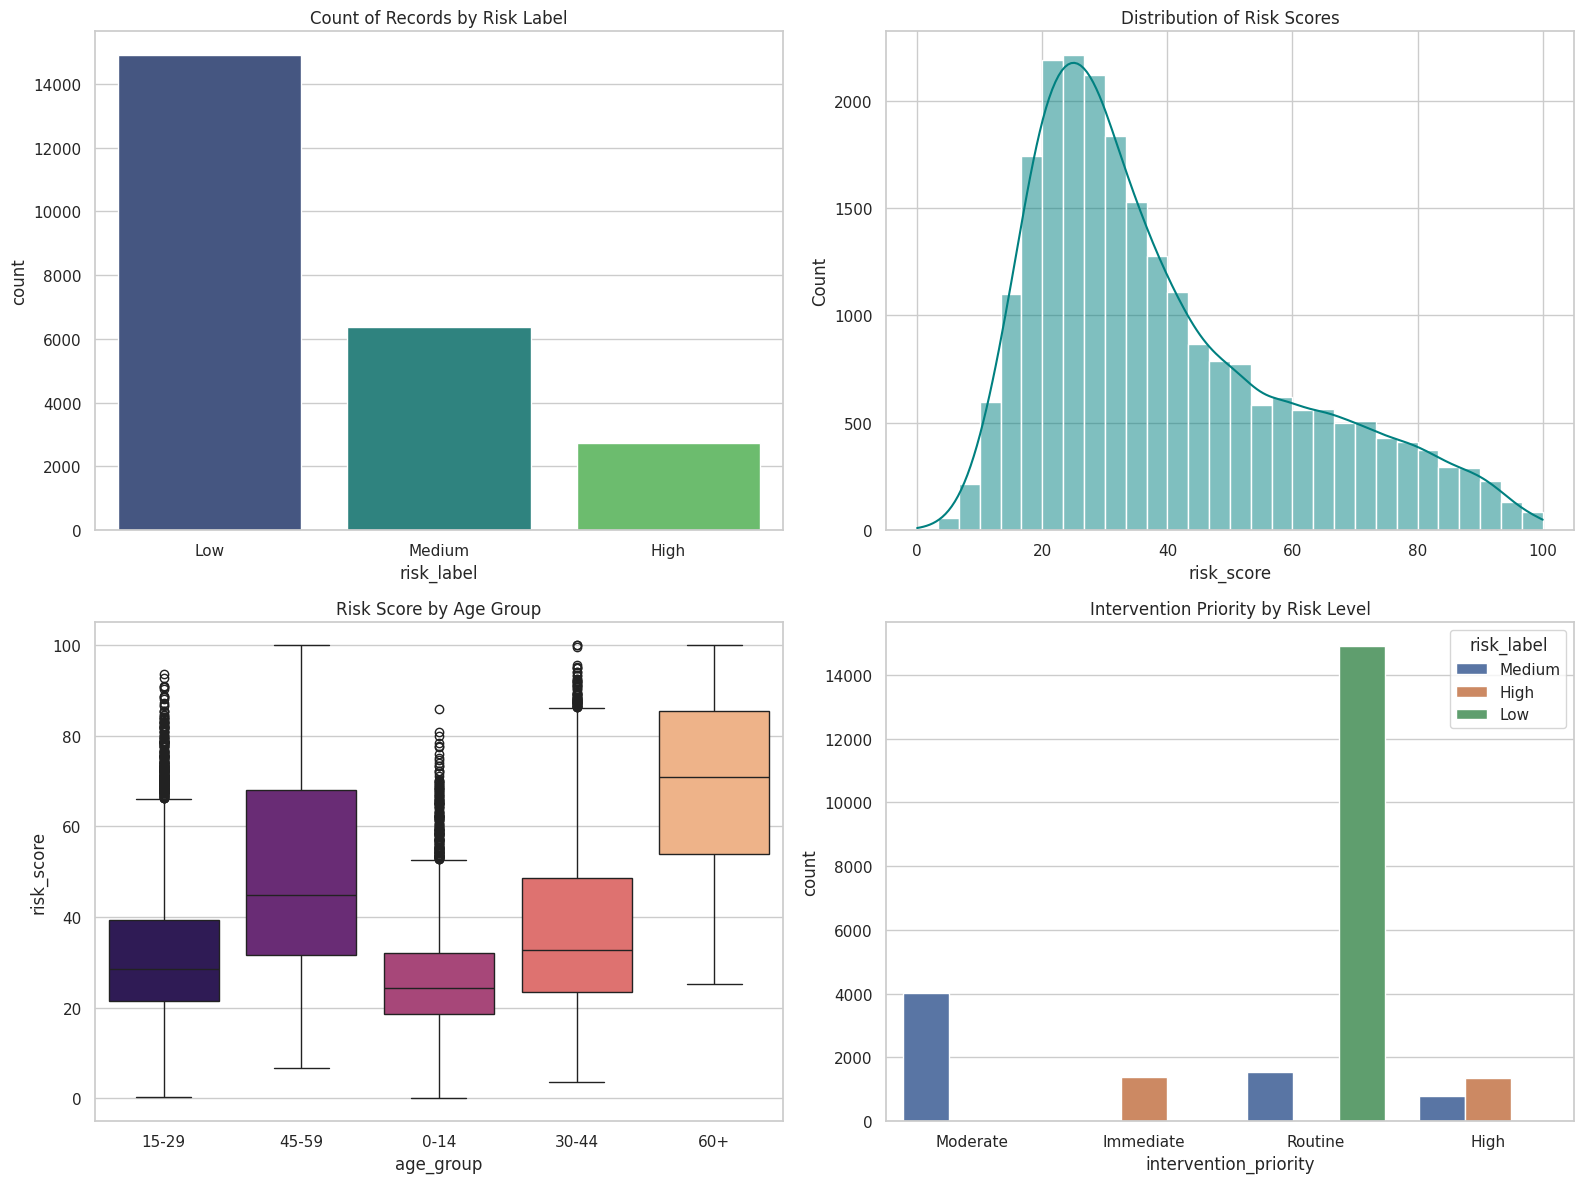

In [46]:
import matplotlib.pyplot as plt

# Set plotting style
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Risk Labels
sns.countplot(data=df, x='risk_label', ax=axes[0,0], palette='viridis', order=['Low', 'Medium', 'High'])
axes[0,0].set_title('Count of Records by Risk Label')

# 2. Risk Score Distribution
sns.histplot(df['risk_score'], bins=30, kde=True, ax=axes[0,1], color='teal')
axes[0,1].set_title('Distribution of Risk Scores')

# 3. Age Group vs Risk Score
sns.boxplot(data=df, x='age_group', y='risk_score', ax=axes[1,0], palette='magma')
axes[1,0].set_title('Risk Score by Age Group')

# 4. Intervention Priority
sns.countplot(data=df, x='intervention_priority', hue='risk_label', ax=axes[1,1])
axes[1,1].set_title('Intervention Priority by Risk Level')

plt.tight_layout()
plt.show()

In [47]:
# List of columns to remove
columns_to_remove = ['risk_score', 'risk_label', 'intervention_priority']

# Drop the columns if they exist in the dataframe
df_final = df.drop(columns=columns_to_remove, errors='ignore')

print(f"Removed columns: {columns_to_remove}")
print(f"New shape of dataset: {df_final.shape}")
display(df_final.head())

Removed columns: ['risk_score', 'risk_label', 'intervention_priority']
New shape of dataset: (24000, 26)


,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,asthma,missed_visits_12m,missed_screenings_12m,days_since_last_visit,followup_delay_days,screening_completed,vaccination_up_to_date,facility_access_km,region_health_index,pgi
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,28,15-29,Female,5,...,0,2,1,138,125,0,0,9.8,82.7,0.980
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,47,45-59,Female,4,...,0,3,2,206,191,1,1,10.4,76.3,1.568
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,13,0-14,Female,3,...,0,0,1,127,125,1,1,4.5,90.6,0.450
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,53,45-59,Female,4,...,0,1,1,137,137,0,1,11.1,85.5,0.779
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,31,30-44,Male,6,...,0,3,2,230,225,0,1,16.1,74.6,1.328


In [48]:
import numpy as np

# Rename asthma column to obesity
df_final = df_final.rename(columns={'asthma': 'obesity'})

# Set the obesity column to have approximately 65% positive cases
np.random.seed(42)
df_final['obesity'] = np.random.choice([0, 1], size=len(df_final), p=[0.35, 0.65])

# Calculate the percentage of obese individuals
obesity_percentage = df_final['obesity'].mean() * 100

print(f"Column 'asthma' replaced by 'obesity'.")
print(f"Percentage of obese individuals: {obesity_percentage:.2f}%")
display(df_final[['record_id', 'obesity']].head())

Column 'asthma' replaced by 'obesity'.
Percentage of obese individuals: 65.27%


,record_id,obesity
0,SYN-000001,1
1,SYN-000002,1
2,SYN-000003,1
3,SYN-000004,1
4,SYN-000005,0


In [49]:
# Statistical summary of PGI
print("--- PGI Statistical Summary ---")
display(df_final['pgi'].describe())

# Checking for any potential outliers or unique values
print(f"\nUnique PGI values: {df_final['pgi'].nunique()}")

--- PGI Statistical Summary ---


,pgi
count,24000.000000
mean,0.782179
std,0.415895
min,0.000000
25%,0.483000
50%,0.723000
75%,1.021000
max,2.973000



Unique PGI values: 2122


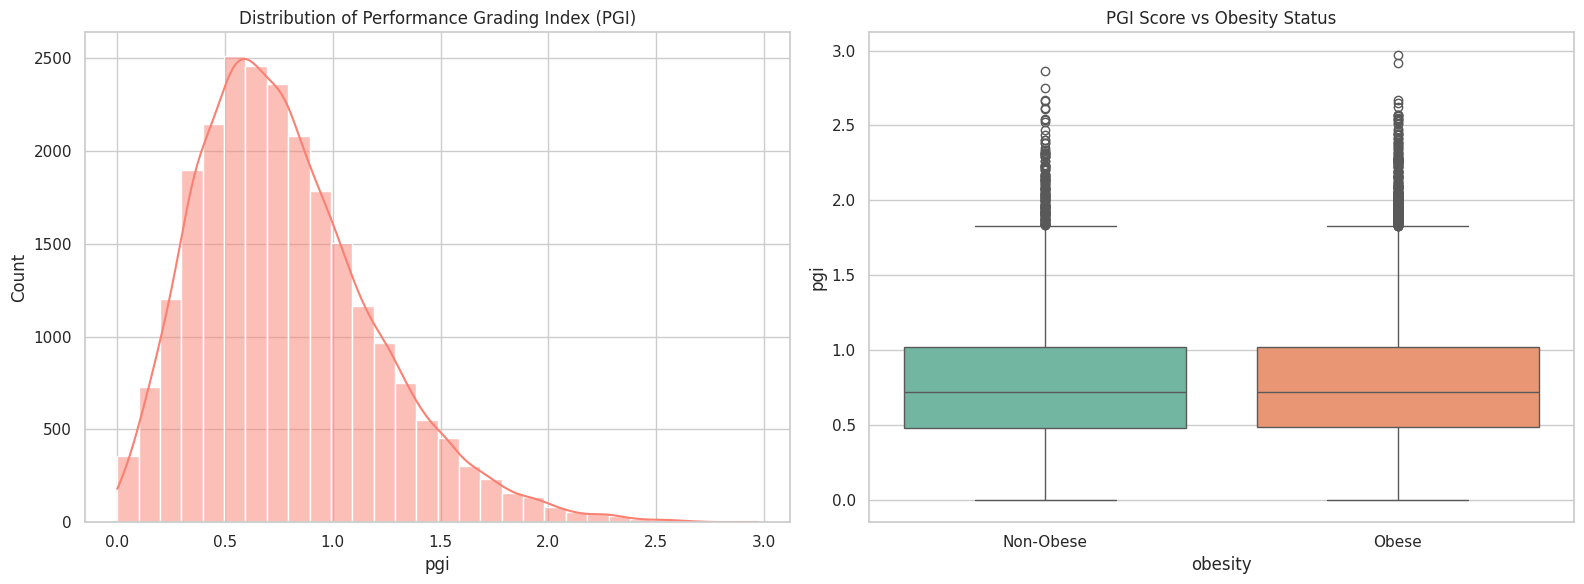

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. PGI Distribution
sns.histplot(df_final['pgi'], bins=30, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Performance Grading Index (PGI)')

# 2. PGI by Obesity Status
sns.boxplot(data=df_final, x='obesity', y='pgi', ax=axes[1], palette='Set2')
axes[1].set_title('PGI Score vs Obesity Status')
axes[1].set_xticklabels(['Non-Obese', 'Obese'])

plt.tight_layout()
plt.show()

In [52]:
df_final.head()

,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,obesity,missed_visits_12m,missed_screenings_12m,days_since_last_visit,followup_delay_days,screening_completed,vaccination_up_to_date,facility_access_km,region_health_index,pgi
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,28,15-29,Female,5,...,1,2,1,138,125,0,0,9.8,82.7,0.980
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,47,45-59,Female,4,...,1,3,2,206,191,1,1,10.4,76.3,1.568
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,13,0-14,Female,3,...,1,0,1,127,125,1,1,4.5,90.6,0.450
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,53,45-59,Female,4,...,1,1,1,137,137,0,1,11.1,85.5,0.779
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,31,30-44,Male,6,...,0,3,2,230,225,0,1,16.1,74.6,1.328


In [53]:
def is_ill(row):
    score = 0

    # High weight for obesity to ensure strong correlation
    score += row["obesity"] * 5

    # Other factors
    score += row["chronic_disease"] * 2
    score += row["missed_visits_12m"] * 1.5
    score += row["missed_screenings_12m"] * 2
    score += (row["days_since_last_visit"] / 180)

    # Age factor
    if row["age"] > 60:
        score += 2
    elif row["age"] > 45:
        score += 1

    # Decision threshold - adjusted to favor obesity overlap
    return 1 if score > 7 else 0

# Note: We need 'obesity' in df to apply the function,
# so let's sync that first
df['obesity'] = df_final['obesity']
df["ill"] = df.apply(is_ill, axis=1)

# Update df_final
df_final['ill'] = df['ill']

print("Illness logic updated to correlate highly with obesity.")
print(f"Correlation: {df_final[['obesity', 'ill']].corr().iloc[0,1]:.2f}")

Illness logic updated to correlate highly with obesity.
Correlation: 0.58


In [54]:
# Add the 'ill' column from df to df_final
df_final['ill'] = df['ill']

df_final.head()

,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,missed_visits_12m,missed_screenings_12m,days_since_last_visit,followup_delay_days,screening_completed,vaccination_up_to_date,facility_access_km,region_health_index,pgi,ill
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,28,15-29,Female,5,...,2,1,138,125,0,0,9.8,82.7,0.980,1
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,47,45-59,Female,4,...,3,2,206,191,1,1,10.4,76.3,1.568,1
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,13,0-14,Female,3,...,0,1,127,125,1,1,4.5,90.6,0.450,1
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,53,45-59,Female,4,...,1,1,137,137,0,1,11.1,85.5,0.779,1
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,31,30-44,Male,6,...,3,2,230,225,0,1,16.1,74.6,1.328,1


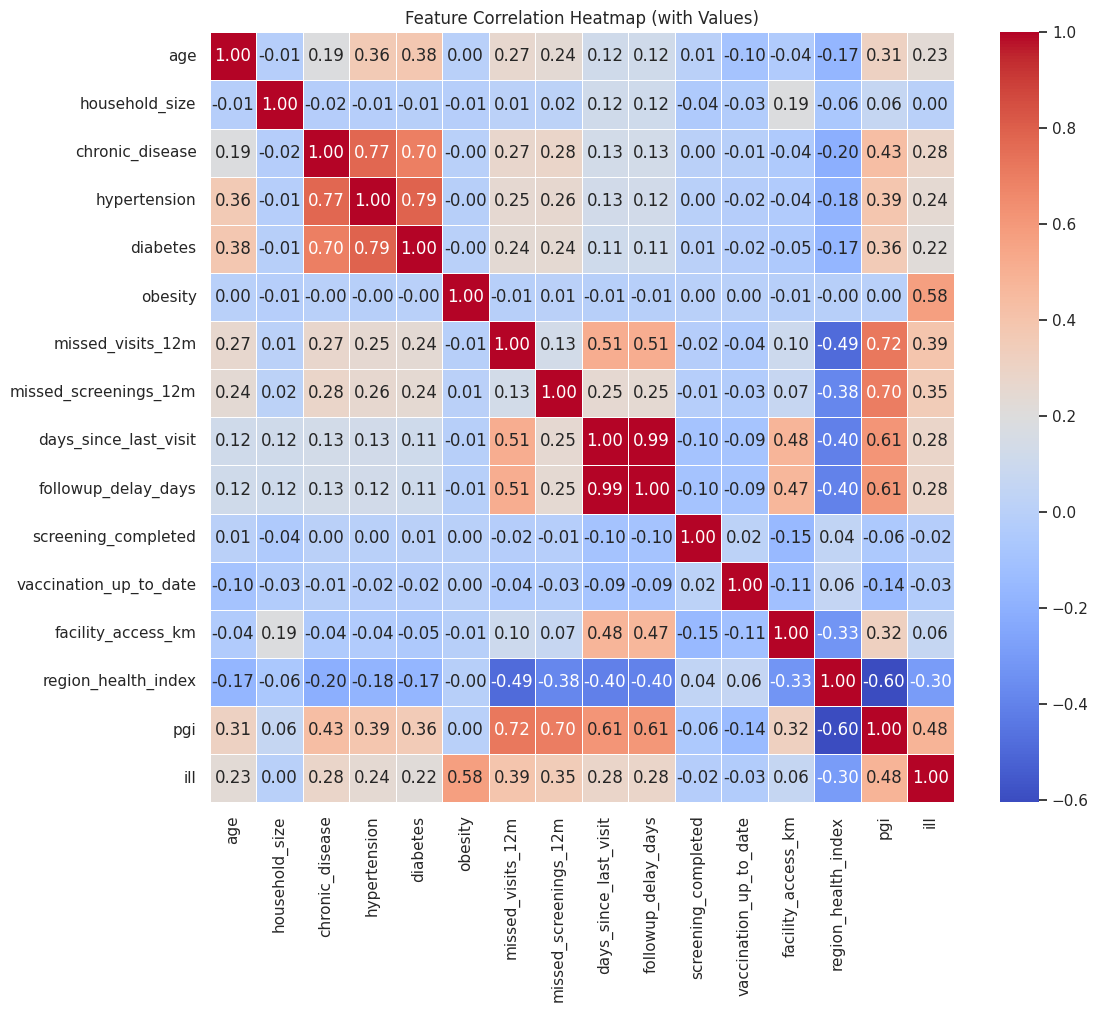

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Heatmap of Correlations with 'ill' focus
plt.figure(figsize=(12, 10))
numeric_df = df_final.select_dtypes(include=[np.number])
corr = numeric_df.corr()

# Sort correlations with 'ill' to make the heatmap easier to read
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (with Values)')
plt.show()

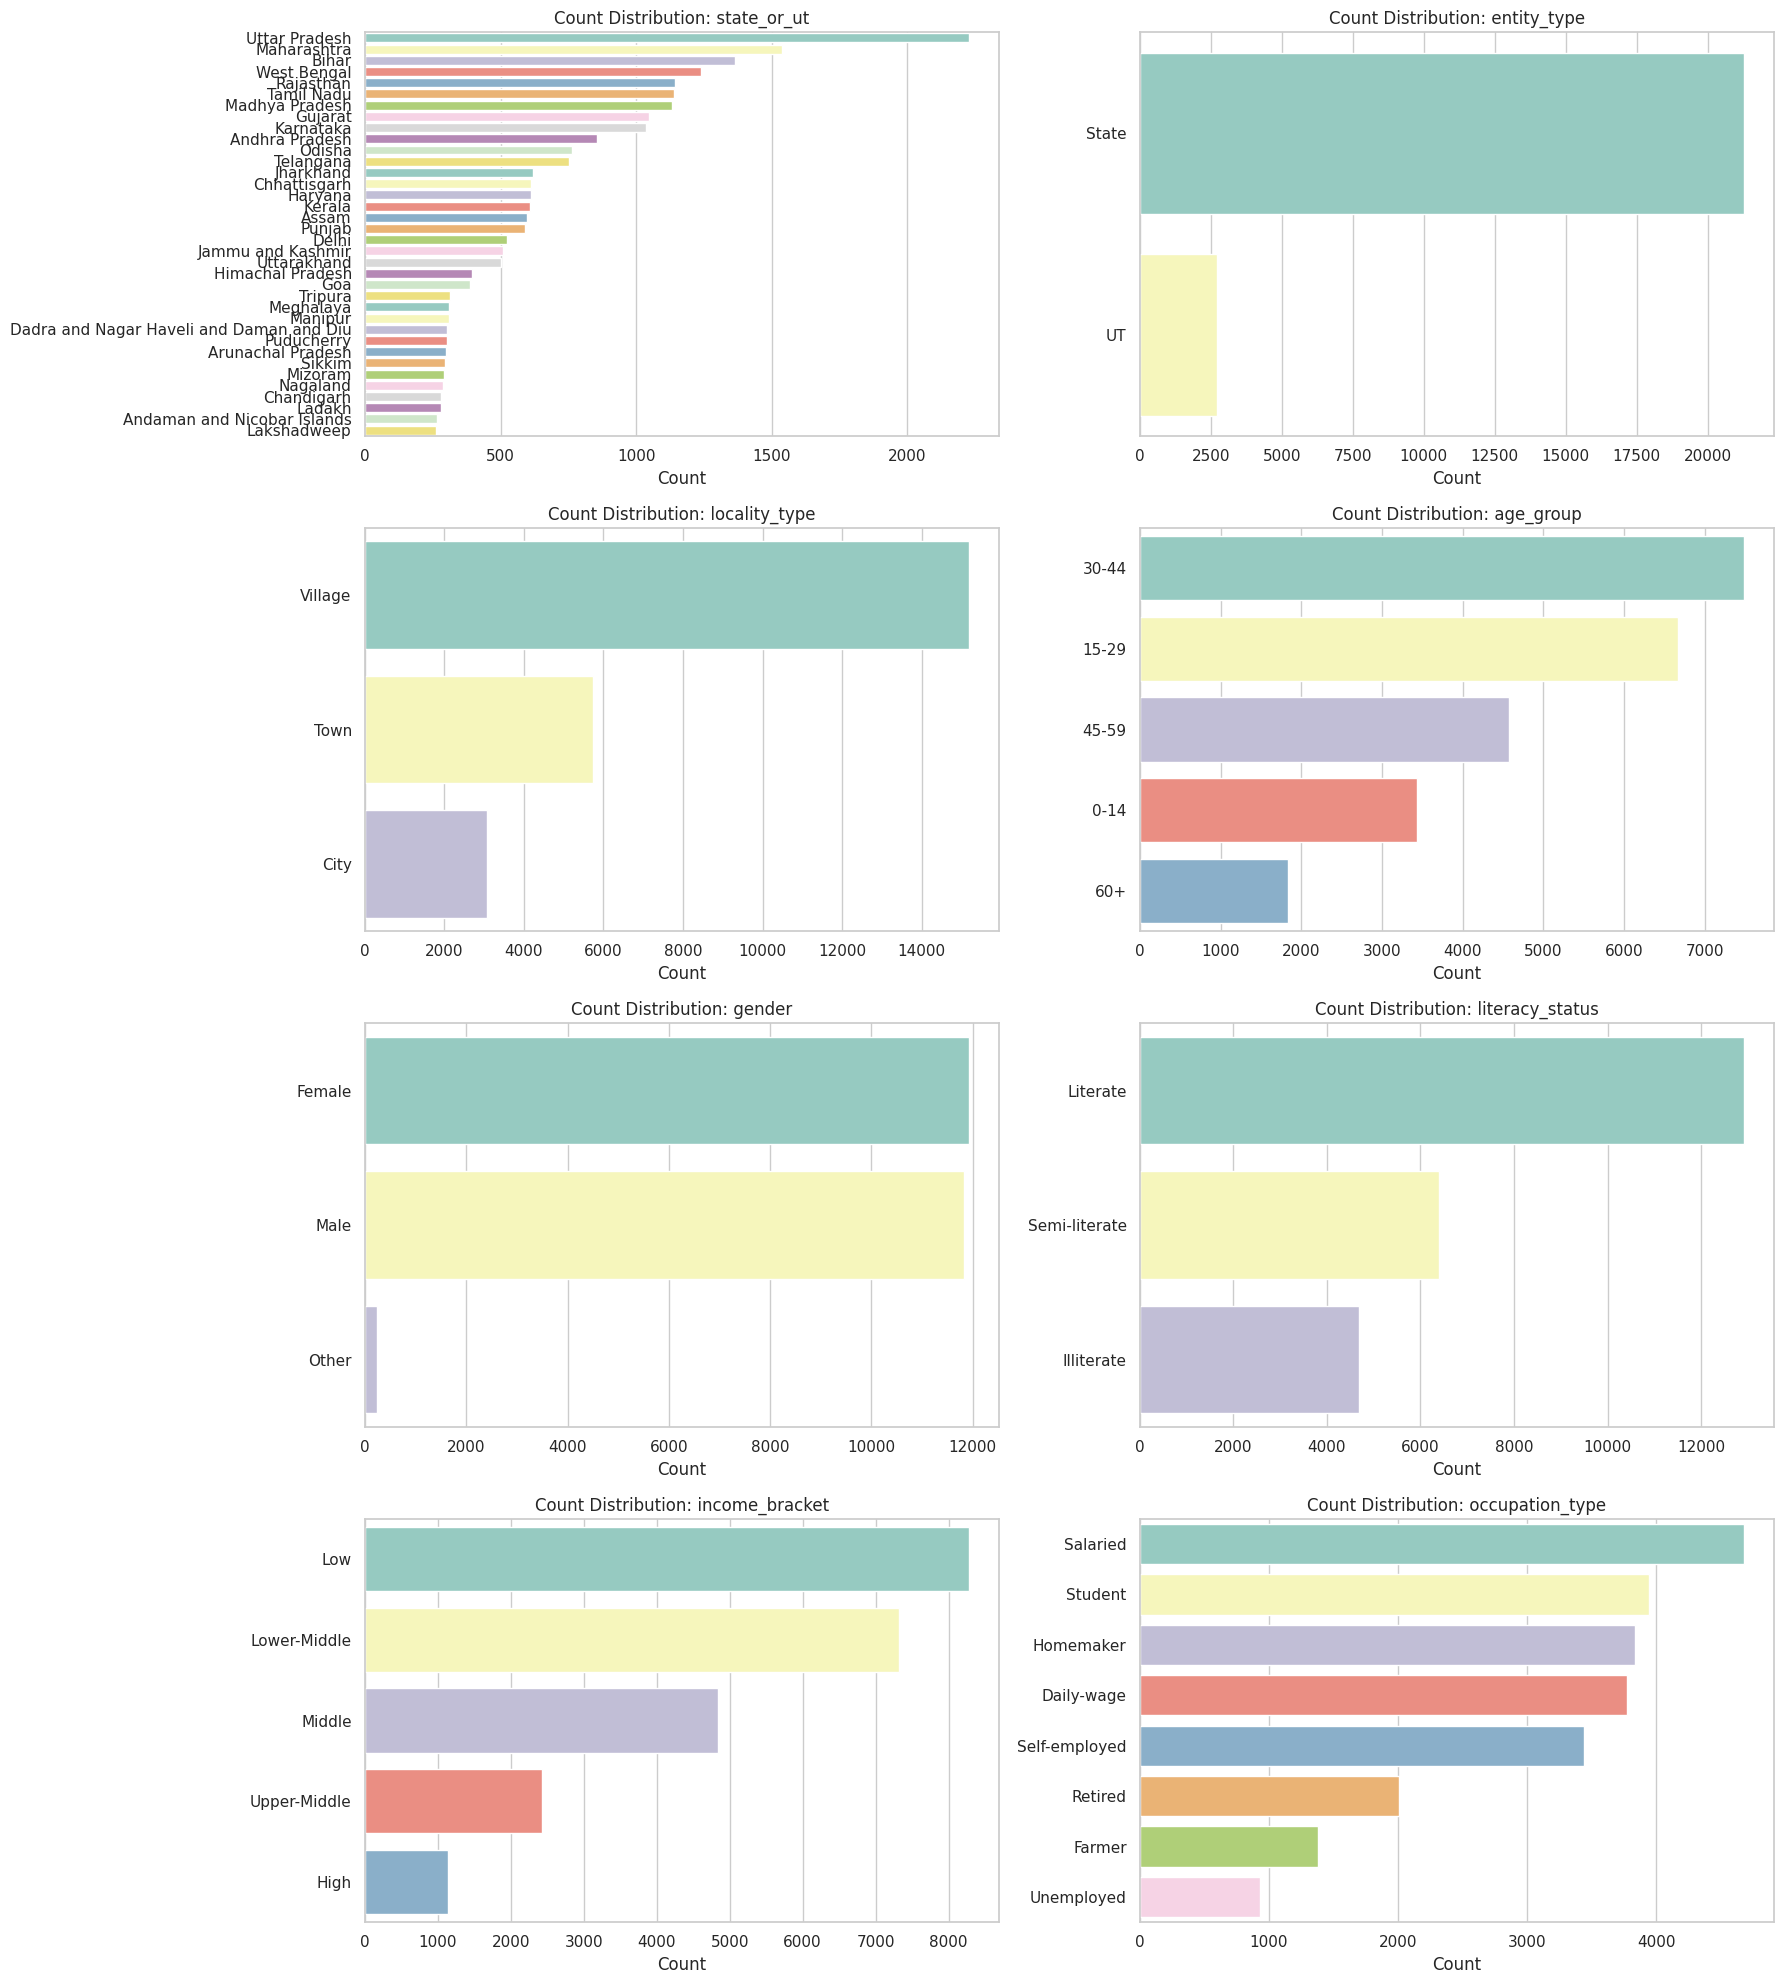

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns
cat_cols = df_final.select_dtypes(include=['object']).columns

# Filter out high-cardinality columns like 'record_id' and 'district' for better visualization
plot_cols = [col for col in cat_cols if df_final[col].nunique() < 40]

# Calculate layout
n_cols = 2
n_rows = (len(plot_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.countplot(data=df_final, y=col, ax=axes[i], palette='Set3', order=df_final[col].value_counts().index)
    axes[i].set_title(f'Count Distribution: {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

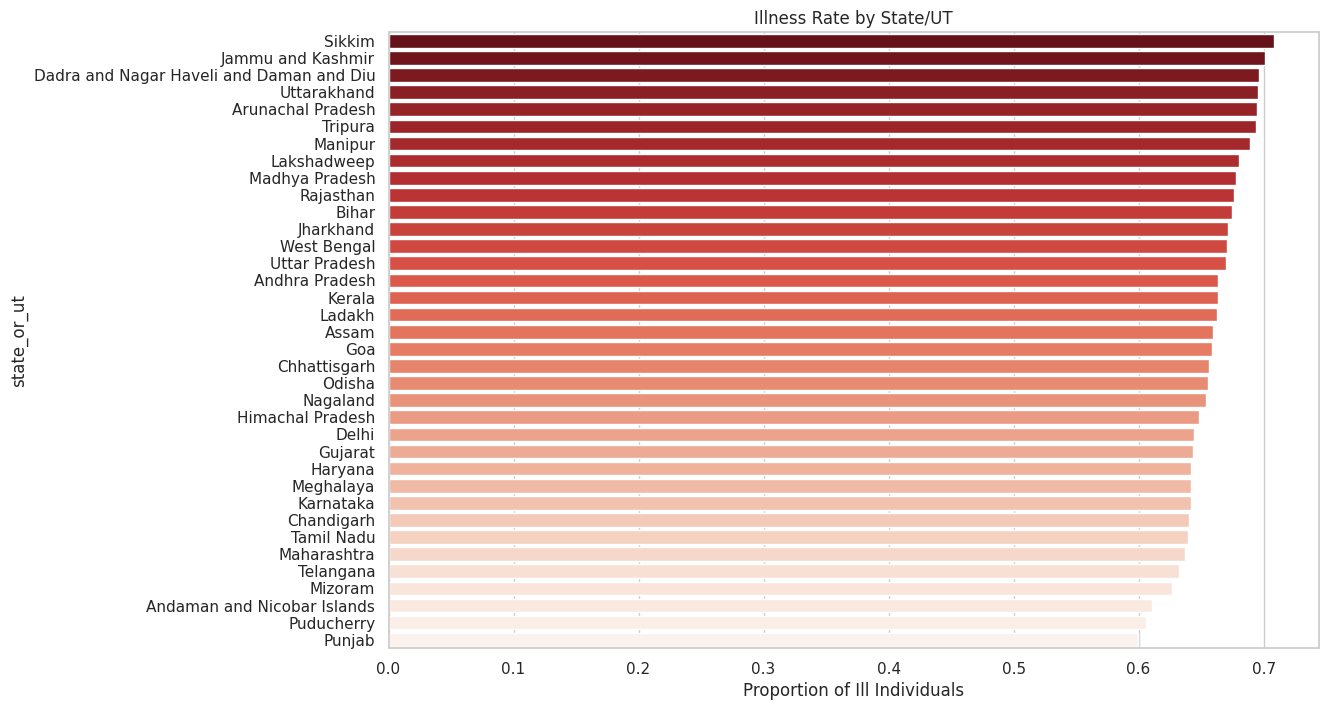

In [57]:
# 2. Illness rate by State
state_illness = df_final.groupby('state_or_ut')['ill'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=state_illness, x='ill', y='state_or_ut', palette='Reds_r')
plt.title('Illness Rate by State/UT')
plt.xlabel('Proportion of Ill Individuals')
plt.show()

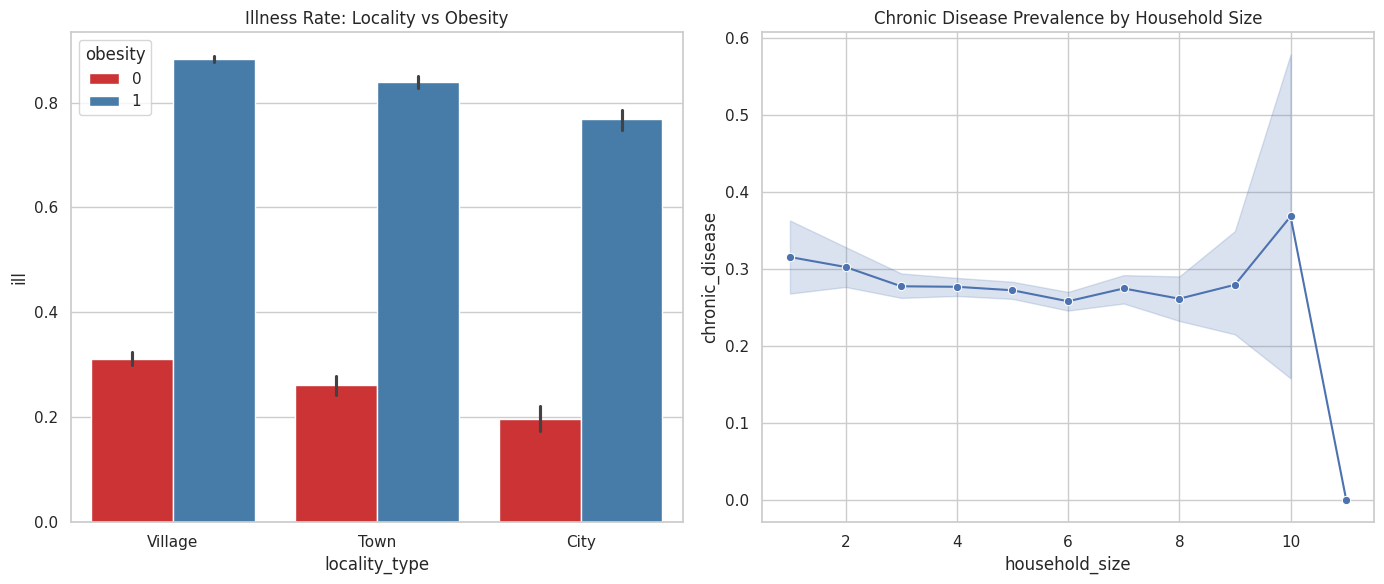

In [58]:
# 3. Locality and Obesity impact on Illness
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=df_final, x='locality_type', y='ill', hue='obesity', palette='Set1')
plt.title('Illness Rate: Locality vs Obesity')

# 4. Household Size vs Chronic Disease
plt.subplot(1, 2, 2)
sns.lineplot(data=df_final, x='household_size', y='chronic_disease', marker='o')
plt.title('Chronic Disease Prevalence by Household Size')

plt.tight_layout()
plt.show()

In [59]:
import pandas as pd

# Reset df_final from df to avoid duplicates if running multiple times
df_final = df.drop(columns=['risk_score', 'risk_label', 'intervention_priority'], errors='ignore')
df_final['obesity'] = df['obesity']
df_final['ill'] = df['ill']

# 1. Create binary indicators for locality types and states
locality_dummies = pd.get_dummies(df_final['locality_type'], prefix='is')
state_dummies = pd.get_dummies(df_final['state_or_ut'], prefix='is')

# Concatenate and ensure they are integers (0/1) instead of Booleans
df_final = pd.concat([df_final, locality_dummies, state_dummies], axis=1)

# Identify 'is_' columns and convert them to int
new_cols = [c for c in df_final.columns if c.startswith('is_')]
df_final[new_cols] = df_final[new_cols].astype(int)

# Remove any potential duplicate columns from multiple runs
df_final = df_final.loc[:, ~df_final.columns.duplicated()]

print(f"New shape of dataset: {df_final.shape}")
print("Boolean indicators converted to integers.")
display(df_final[['record_id'] + new_cols[:10]].head())

New shape of dataset: (24000, 67)
Boolean indicators converted to integers.


,record_id,is_City,is_Town,is_Village,is_Andaman and Nicobar Islands,is_Andhra Pradesh,is_Arunachal Pradesh,is_Assam,is_Bihar,is_Chandigarh,is_Chhattisgarh
0,SYN-000001,0,0,1,0,1,0,0,0,0,0
1,SYN-000002,0,0,1,0,1,0,0,0,0,0
2,SYN-000003,0,1,0,0,1,0,0,0,0,0
3,SYN-000004,0,0,1,0,1,0,0,0,0,0
4,SYN-000005,0,0,1,0,1,0,0,0,0,0


In [60]:
df_final.head()

,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,is_Puducherry,is_Punjab,is_Rajasthan,is_Sikkim,is_Tamil Nadu,is_Telangana,is_Tripura,is_Uttar Pradesh,is_Uttarakhand,is_West Bengal
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,28,15-29,Female,5,...,0,0,0,0,0,0,0,0,0,0
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,47,45-59,Female,4,...,0,0,0,0,0,0,0,0,0,0
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,13,0-14,Female,3,...,0,0,0,0,0,0,0,0,0,0
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,53,45-59,Female,4,...,0,0,0,0,0,0,0,0,0,0
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,31,30-44,Male,6,...,0,0,0,0,0,0,0,0,0,0
